# Homework 3: Autodiff

This week, you will implement a set of functions to perform automatic differentiation (autodiff) and train a multi-layer perceptron using that framework. The assignment has three key tasks:

1. Complete the "Operation" class, which runs forward and backward pass for input vectors (Section 1.a, Section 2.a).
2. Complete the "Node" class, which forms a logical computation unit in a computation graph (Section 1.b).
3. Train an MLP built using your autodiff framework (Section 2).

Autodiff is the foundation of how modern neural networks are trained. This assignment gives you a taste of how it operates under the hood. Let's build it step-by-step!

**Some helpful links** (if you want to familiarize yourself with frameworks implementing autodiff)

* https://www.cs.toronto.edu/~rgrosse/courses/csc421_2019/readings/L06%20Automatic%20Differentiation.pdf
* https://github.com/HIPS/autograd/blob/master/docs/tutorial.md
* https://videolectures.net/videos/deeplearning2017_johnson_automatic_differentiation

This cell below imports the necessary Python libraries for data generation, preprocessing, and visualization. These include tools for creating synthetic datasets, one-hot encoding, and plotting results using Matplotlib and Graphviz.

In [1]:
# ============================================
# DO NOT MODIFY THIS CELL
# ============================================

import random
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import make_moons
# import networkx as nx
from graphviz import Digraph
import matplotlib.pyplot as plt

# 1. Autodiff from scratch

## 1.1 Build arithmetic operation classes

The cell below defines a base class `Operation` that supports differentiable arithmetic operations such as `Add`, `Mul`, `ReLU`, and `MatMul`. Each operation will implement two key methods:  

- `forward()` computes the result of the arithmetic operation on the input vectors.
- `_backward()` computes the gradients with respect to the input vectors.  

During the backward pass, NumPy's broadcasting rules can cause gradient shapes to differ from the shapes of the original inputs. To handle this, the parent `Operation` class calls `unbroadcast()`, which adjusts gradients so they match the original input dimensions.

For example:
```
A = np.random.randn(3,4)
B = np.random.randn(3,1)
O = A + B  # produces an array of shape (3,4)
```

Here, $B$ is implicitly expanded across 4 columns to match the shape of $A$. When computing the gradient of $O$ with respect of $A$ and $B$, the shapes must match the original inputs:

$$\frac{\partial O}{\partial A} \in R^{3 \times 4}, \frac{\partial O}{\partial B} \in R^{3 \times 1}$$

In case of addition, both gradients are equal to the upstream gradient $\frac{\partial O}{\partial O}$, which has shape 3 x 4. To make the gradient for $B$ match its orginal shape, we must sum across the broadcasted dimension (the 4 columns). The **unbroadcast()** function handles this adjustment; it sums and reshapes gradients to undo broadcasting from the forward pass.

In [2]:
# ============================================
# DO NOT MODIFY THIS CELL
# ============================================

def unbroadcast(grad, target):
    '''
    Adjusts a gradient tensor to match the shape of a target tensor
    after broadcasting.

    This function reverses NumPy-style broadcasting by summing over
    the extra dimensions in `grad` and over any axes where `target`
    has size 1. It is often used during backpropagation to correctly
    aggregate gradients for broadcasted operations.

    Args:
        grad (np.ndarray): The gradient array with a possibly broadcasted
                           shape.
        target (np.ndarray): The original array whose shape the gradient
                             should match.

    Returns:
        np.ndarray: The gradient reshaped (by summation) to match
                    `target.shape`.
    '''
    while grad.ndim > target.ndim:
        grad = grad.sum(axis=0)

    for axis, size in enumerate(target.shape):
        if size == 1:
            grad = grad.sum(axis=axis, keepdims=True)
    return grad

class Operation:
    '''
    Base class for differentiable operations in a computational graph.

    Child classes must implement `forward` and `_backward`. The `backward` method
    handles gradient propagation and shape correction via `unbroadcast`.
    '''

    def forward(self, *inputs):
        '''
        Defines the forward computation.
        Must be implemented in the child class.

        Args:
            *inputs (tuple of np.ndarray): Input arrays.

        Returns:
            np.ndarray: Result of the operation.
        '''

        raise NotImplementedError("Must be implemented in the child class")

    def backward(self, grad_upstream, *inputs):
        '''
        Computes gradients w.r.t. each input and corrects their shapes.

        Args:
            grad_upstream (np.ndarray): Gradient from the next layer.
            *inputs (tuple of np.ndarray): Inputs from the forward pass.

        Returns:
            list of np.ndarray: Gradients matching input shapes.
        '''
        grad = []
        grad_out = self._backward(grad_upstream, *inputs)
        for idx, g in enumerate(grad_out):
            grad.append(unbroadcast(g, inputs[idx]))
        return grad


This cells below define subclasses of the `Operation` class for basic arithmetic and activation functions: Add, Mul, ReLU, and MatMul.

Each class implements the `forward()` and `_backward()` methods, which compute the output of the operation and its gradients with respect to the inputs.
Complete the methods to perform the correct computations for both the forward and backward passes.

In [3]:
class Add(Operation):
    '''
    Represents elementwise addition between two tensors.
    '''

    def __repr__(self):
        return "+"

    def forward(self, x: np.ndarray, y: np.ndarray):
        '''
        Computes the forward pass for elementwise addition.

        Args:
            x, y (np.ndarray): Input arrays to be added.
        Returns:
            np.ndarray: Elementwise sum of x and y.
        '''
        # ===========================================================
        # If x.shape != y.shape, they must be broadcastable to a common shape (which becomes the shape of the output)
        sum = np.add(x, y)
        return sum
        # ===========================================================

    def _backward(self,
                  grad_upstream: np.ndarray,
                  x: np.ndarray,
                  y: np.ndarray
                  ):
        '''
        Computes gradients of the loss w.r.t. x and y.

        Args:
            grad_upstream (np.ndarray): Gradient from the next layer.
            x, y (np.ndarray): Inputs from the forward pass.
        Returns:
            list[np.ndarray]: Gradients w.r.t. x and y.
        '''
        # ===========================================================
        unbroadcasted_x = unbroadcast(grad_upstream, x) 
        unbroadcasted_y = unbroadcast(grad_upstream, y) 

        #Take the example c = a + b 
        # dc_da = 1 and dc_db = 1
      
        d_L_d_o = [(unbroadcasted_x), (unbroadcasted_y)]
        return d_L_d_o
        # ===========================================================


In [4]:
class Mul(Operation):
    '''
    Represents elementwise multiplication between two tensors.
    '''

    def __repr__(self):
        return "*"

    def forward(self, x: np.ndarray, y: np.ndarray):
        '''
        Computes the elementwise product of x and y.

        Args:
            x, y (np.ndarray): Input arrays.
        Returns:
            np.ndarray: Elementwise product of x and y.
        '''
        # ===========================================================
        product = np.multiply(x, y)
        return product
        # ===========================================================

    def _backward(self,
                  grad_upstream: np.ndarray,
                  x: np.ndarray,
                  y: np.ndarray):
        '''
        Computes gradients of the loss w.r.t. x and y.

        Args:
            grad_upstream (np.ndarray): Gradient from the next layer.
            x, y (np.ndarray): Inputs from the forward pass.
        Returns:
            list[np.ndarray]: Gradients w.r.t. x and y.
        '''
        # ===========================================================
        grad_x = unbroadcast(grad_upstream * y, x)
        grad_y = unbroadcast(grad_upstream * x, y)

        #Take the example c = a * b 
        # dc_da = b and dc_db = a
        
        d_L_d_o = [grad_x, grad_y]

        return d_L_d_o
        # ===========================================================


In [5]:
class ReLU(Operation):
    '''
    Represents the ReLU (Rectified Linear Unit) activation function.
    Applies a threshold at zero during the forward pass and propagates
    gradients only through positive inputs during the backward pass.
    '''
    def __repr__(self):
        return "ReLU"

    def forward(self, x: np.ndarray):
        '''
        Computes the forward pass of the ReLU activation function.

        Args:
            x (np.ndarray): Input array.
        Returns:
            np.ndarray: Output of the ReLU activation function.
        '''
        # ===========================================================
        return np.maximum(0, x)
        # ===========================================================

    def _backward(self, grad_upstream: np.ndarray, x: np.ndarray):
        '''
        Computes gradients of the loss w.r.t. the input.

        Args:
            grad_upstream (np.ndarray): Gradient from the next layer.
            x (np.ndarray): Input to the ReLU activation function.
        Returns:
        '''
        # ===========================================================
        local_gradient = np.where(x > 0, 1, 0)
        res = [np.multiply(grad_upstream, local_gradient)]
        return res
        # ===========================================================


In [6]:
class MatMul(Operation):
    '''
    Represents matrix multiplication between two tensors.
    '''
    def __repr__(self):
        return "@"

    def forward(self, x: np.ndarray, y: np.ndarray):
        '''
        Computes the matrix multiplication of x and y.

        Args:
            x, y (np.ndarray): Input arrays.
        Returns:
            np.ndarray: Matrix multiplication of x and y.
        '''
        # ===========================================================
        res = np.matmul(x, y)
        return res
        # ===========================================================

    def _backward(self, grad_upstream: np.ndarray, x: np.ndarray, y: np.ndarray):
        '''
        Computes gradients of the loss w.r.t. x and y.

        Args:
            grad_upstream (np.ndarray): Gradient from the next layer.
            x, y (np.ndarray): Inputs from the forward pass.
        Returns:
            list[np.ndarray]: Gradients w.r.t. x and y.
        '''
        # ===========================================================
        # x @ y = z
        # Let x have dimension a x b 
        # Let y have dimension b x c
        # Therefore, z has dimension a x c 
        
        # If we assume grad_upstream to have the same dimension as z, then it's dimension is a x c 
        
        # dL_do * dz/dy     
        # a x b @ a x c
        # b x a @ a x c = b x c -> x.T * grad_upstream
        
        # dL_do * dz/dx     
        # a x c @ b x c
        # a x c @ c x b = a x b -> grad_upstream * y.T
        
        res = [np.matmul(grad_upstream, y.T), np.matmul(x.T, grad_upstream)]

        return res
        # ===========================================================

Below is an example test for `Add()`. You can write similar tests for the other methods.

In [7]:
import numpy as np

def test_example_add():
    # ---------- Forward Test ----------
    x = np.array([[1.0, 2.0],
                  [3.0, 4.0]])
    y = np.array([[5.0, 6.0],
                  [7.0, 8.0]])
    op = Add()
    out = op.forward(x, y)
    expected_forward = x + y
    print("Forward pass correct:", np.allclose(out, expected_forward))

    # ---------- Backward Test ----------
    grad_upstream = np.ones_like(out)
    grad1, grad2 = op.backward(grad_upstream, x, y)
    expected_grad1 = np.ones_like(x)  # ∂L/∂x = grad_upstream
    expected_grad2 = np.ones_like(y)  # ∂L/∂y = grad_upstream
    print("Backward pass grad1 correct:", np.allclose(grad1, expected_grad1))
    print("Backward pass grad2 correct:", np.allclose(grad2, expected_grad2))

def test_example_mul():
    # ---------- Forward Test ----------
    x = np.array([[1.0, 2.0],
                  [3.0, 4.0]])
    y = np.array([[5.0, 6.0],
                  [7.0, 8.0]])

    op = Mul()
    out = op.forward(x, y)
    expected_forward = x * y

    print("Mul forward pass correct:", np.allclose(out, expected_forward))

    # ---------- Backward Test ----------
    grad_upstream = np.ones_like(out)
    grad_x, grad_y = op.backward(grad_upstream, x, y)

    expected_grad_x = y          # ∂(x*y)/∂x = y
    expected_grad_y = x          # ∂(x*y)/∂y = x

    print("Mul backward grad_x correct:", np.allclose(grad_x, expected_grad_x))
    print("Mul backward grad_y correct:", np.allclose(grad_y, expected_grad_y))

def test_example_relu():
    # ---------- Forward Test ----------
    x = np.array([[-1.0, 2.0],
                  [0.0, 3.0]])

    op = ReLU()
    out = op.forward(x)
    expected_forward = np.array([[0.0, 2.0],
                                 [0.0, 3.0]])

    print("ReLU forward pass correct:", np.allclose(out, expected_forward))

    # ---------- Backward Test ----------
    grad_upstream = np.ones_like(out)
    grad_x = op.backward(grad_upstream, x)

    expected_grad_x = np.array([[0.0, 1.0],
                                [0.0, 1.0]])

    print("ReLU backward pass correct:", np.allclose(grad_x, expected_grad_x))

def test_example_matmul():
    # ---------- Forward Test ----------
    x = np.array([[1.0, 2.0],
                  [3.0, 4.0]])     # (2 × 2)
    y = np.array([[5.0, 6.0],
                  [7.0, 8.0]])     # (2 × 2)

    op = MatMul()
    out = op.forward(x, y)
    expected_forward = x @ y

    print("MatMul forward pass correct:", np.allclose(out, expected_forward))

    # ---------- Backward Test ----------
    grad_upstream = np.ones_like(out)

    grad_x, grad_y = op.backward(grad_upstream, x, y)

    expected_grad_x = grad_upstream @ y.T
    expected_grad_y = x.T @ grad_upstream

    print("MatMul backward grad_x correct:", np.allclose(grad_x, expected_grad_x))
    print("MatMul backward grad_y correct:", np.allclose(grad_y, expected_grad_y))




# Run the test
test_example_add()
test_example_mul()
test_example_relu()
test_example_matmul()



Forward pass correct: True
Backward pass grad1 correct: True
Backward pass grad2 correct: True
Mul forward pass correct: True
Mul backward grad_x correct: True
Mul backward grad_y correct: True
ReLU forward pass correct: True
ReLU backward pass correct: True
MatMul forward pass correct: True
MatMul backward grad_x correct: True
MatMul backward grad_y correct: True


## 1.2 Node class

With the Operation class set up, the next step is to complete the Node class. At a high-level, the Node class works as follows:

* A `Node` represents a logical unit of computation in the computation graph.

* Every Node stores a value (array).

* An input Node (or value Node) only stores its value. Any other Node produced as a result of Operation stores the
    1. Operation used to create the Node and
    2. the reference to its parent Nodes (inputs to the Operation).

* Except for the input Node, the value of a Node is computed only when `forward()` method is called (see Note #1 below).

* The `backward()` method applies the chain rule to propagate and accumulate gradients for each Node (self.grad).

* `topo_sort()` traverses the set of Nodes and sorts them in topological order. This ordering is necessary for both `forward()` and `_backward()` functions to process the Nodes in a correct sequence.

**NOTE**

1. The apporach that delays the computation of the forward values is called *lazy evaluation*, which was used in frameworks like Theano and Tensorflow 1.x. In contrast, modern PyTorch and Tensorflow 2.x implement *eager execution*, which computes the values immediately as they are created. Lazy evaluation can still be beneficial, as it allows for global graph-level optimizations.

2. You can visualize the computation graph formed by the Nodes using `visualize_computation_graph()` function provided below.

In [8]:
class Node:
    '''
    Represents a node in the computation graph.

    Each Node stores:
    - its computed value (NumPy array),
    - the operation (op) that created it,
    - references to its parent nodes (inputs),
    - and its accumulated gradient (grad).
    '''
    def __init__(self, name=None, value=None):
        self.name = name
        self.value = np.array(value)
        self.op = None
        self.parents = []
        self.grad = 0

    def __repr__(self):
        return f"(value {self.value}, op {self.op}, parents {self.parents})"

    def forward(self):
        '''
        Computes the forward pass for all nodes in the computation graph.

        Performs a topological sort to ensure that each node’s parents
        are computed before the node itself. For each non-input node,
        calls its operation’s forward() method to compute its value.
        '''

        # Perform topological sort of the nodes
        topo_order = topo_sort(self)
        # Iterate through the sorted nodes to compute and
        # store each node’s forward value.
        for node in topo_order:
            if node.op is not None:
                #################### YOUR CODE ####################
                inputs = [parent.value for parent in node.parents]
                node.value = node.op.forward(*inputs)
                ###################################################

    def backward(self):
        '''
        Computes the backward pass (backpropagation) for all nodes.

        Traverses nodes in reverse topological order to apply the chain rule.
        Each node uses its operation’s backward() method to compute gradients
        w.r.t. its parent nodes and accumulates them in parent.grad.
        '''

        # Perform topological sort of the nodes
        topo_order = topo_sort(self)

        # Set the gradients w.r.t current node as 1
        self.grad = np.ones_like(self.value)

        # Iterate through the sorted nodes to compute and
        # accumulate gradients for each node.
        for node in topo_order[::-1]:
            if node.op is not None:
                # Perform backward pass of the current node
                # And propagate the current node's gradient to its parents
                # ===========================================================
                inputs = [parent.value for parent in node.parents]

                gradients = node.op.backward(node.grad, *inputs)

                for i in range(len(node.parents)):
                  node.parents[i].grad += gradients[i]
                # ===========================================================


This method below returns the nodes of a computation graph in topological order, ensuring that each node's parents appear before the node itself.
It uses a depth-first search (DFS) traversal to visit all parent nodes and build the correct dependency order for forward and backward computations.

In [9]:
def dfs_recursive(node, visited, topo_order):
    if node in visited:
        return 
    
    visited.add(node)

    for parent in node.parents:
        if parent not in visited: 
            dfs_recursive(parent, visited, topo_order)

    topo_order.append(node)
    


def topo_sort(node):
    '''
    Use a graph traversal algorithm to generate a topological
    ordering of the nodes, following the dependencies in the
    computation graph.
    '''
    # ===========================================================
    # TODO
    topo_order = []

    visited = set()
    
    dfs_recursive(node, visited, topo_order)
    

    # Input Node: 
        # x = Node(name="x", value=[[1, 2], [3, 4]])
        # y = Node(name="y", value=[[5, 6], [7, 8]])

    # Second Node 
    # z1 = Node()
    # z1.op = MatMul()
    # z1.parents = [x, y]
    # z1.value = x.value @ y.value

    # Third Node
    # z2 = Node()
    # z2.op = ReLU()
    # z2.parents = [z1]
    # z2.value = np.maximum(0, z1.value)

    # Example Topo_Order = x, y, z1, z2 

      
    dfs_recursive(node, visited, topo_order)
 

    return topo_order
    # ===========================================================




This method below creates and returns a new `Node` that records its parent nodes, the operation that produced it, and optionally its name and value.

In [10]:
def get_node(parents, op, name=None, value=None):
    '''
    Creates and returns a new Node in the computation graph.
    '''
    n = Node(name=name, value=value)
    n.parents=parents
    n.op=op
    return n

Below is some sample code to create a cmoputational graph and run forward and backward pass on it.

In [11]:
# --- Build a tiny computation graph and sanity-check forward/backward ---

# Inputs (leaf/value nodes)
node_a = get_node(name='node_a', value=np.random.randn(2, 2), parents=[], op=None)
node_b = get_node(name='node_b', value=np.random.randn(2, 2), parents=[], op=None)

# Internal node: C = A + B
node_c = get_node(name='node_c', parents=[node_a, node_b], op=Add())

# Final node: O = C * A  (elementwise multiply)
final_node = get_node(name='final_node', parents=[node_c, node_a], op=Mul())

# ----- Forward pass -----
final_node.forward()

# Expected forward values
expected_c = node_a.value + node_b.value
expected_final = expected_c * node_a.value

print("Forward C correct:", np.allclose(node_c.value, expected_c))
print("Forward final correct:", np.allclose(final_node.value, expected_final))

# ----- Backward pass -----
final_node.backward()

# With L = sum(final_node.value), dL/d(final) = 1 -> seeded by Node.backward
# Gradients:
# dL/dC = A
# dL/dA (from final mul) = C
# dL/dA (from add path)  = dL/dC = A
# => grad_A = C + A = (A + B) + A = 2A + B
# => grad_B = dL/dC = A

expected_grad_c = node_a.value
expected_grad_a = (node_a.value + node_b.value) + node_a.value  # 2A + B
expected_grad_b = node_a.value
expected_grad_final = np.ones_like(final_node.value)

print("Backward grad C correct:", np.allclose(node_c.grad, expected_grad_c))
print("Backward grad A correct:", np.allclose(node_a.grad, expected_grad_a))
print("Backward grad B correct:", np.allclose(node_b.grad, expected_grad_b))
print("Backward grad final correct:", np.allclose(final_node.grad, expected_grad_final))

# Optional: visualize the graph
#visualize_computation_graph(final_node)


Forward C correct: True
Forward final correct: True
Backward grad C correct: True
Backward grad A correct: True
Backward grad B correct: True
Backward grad final correct: True


Feel free to use the function below to visualize a computation graph.

In [12]:
def visualize_computation_graph(node):
    dot = Digraph(format="png", graph_attr={"rankdir": "LR"})
    visited = set()

    def add_nodes(n):
        if n in visited:
            return
        visited.add(n)

        # Add current node
        dot.node(str(id(n)), label=f"{str(n.name)}\nop: {str(n.op)}\nshape: {n.value.shape}")

        # Add edges to parents
        if hasattr(n, "parents"):
            for p in n.parents:
                dot.edge(str(id(p)), str(id(n)))
                add_nodes(p)

    add_nodes(node)
    return dot

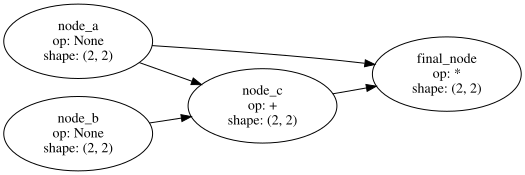

In [13]:
visualize_computation_graph(final_node)

# 2.1: Build MLP with autodiff

Now you will use the autodiff framework you built to train an MLP model. In week 2, you trained an MLP by explicitly applying the derived partial derivatives. This time, you will rely on your autodiff framework to automatically compute and propagate the gradients through the network!

For initializing the weights and biases of the layer, use the same initialization that has been provided to you in week 2 homework.

## 2.a Build a basic MLP model (0.5 point)

In [14]:
class Layer:
    def __init__(self, input_dim, output_dim):
        ############### YOUR CODE ################
        # TODO: use the Node() class to produce
        #       weights and biases of the layer
        #       Implement the same initialization that has been used
        #       from week 2 homework.
        
        weight_value = np.random.randn(
            output_dim, input_dim
        ) * np.sqrt(2.0 / input_dim)

        bias_value = np.zeros((output_dim, 1))

        self.weights = Node(name="weight_node", value=weight_value)
        self.biases = Node(name="bias_node", value=bias_value)
       
        ###########################################

    def __call__(self, X: Node) -> Node:
        ############### YOUR CODE ################
        ## TODO: Use get_node() to compute (Wx + b)
        #        then apply ReLU to the output

        node_m = get_node(name='node_m', parents=[self.weights, X], op=MatMul())
        

        node_z = get_node(name='node_z', parents=[self.biases, node_m], op=Add())

        node_relu = get_node(name='node_relu', parents=[node_z], op=ReLU())
        
        out = node_relu
        return out
        ###########################################

    def parameters(self):
        return [self.weights, self.biases]

In [15]:
class LinearMLP:
    def __init__(self, layer_widths):
        self.layers = []
        ############### YOUR CODE ################
        ## TODO: Create the layers of MLP.
        ## Hint: Include the ReLU after the very last linear layer!
        ##########################################

        for i in range(len(layer_widths) - 1):
            d_in = layer_widths[i]
            d_out = layer_widths[i + 1]

            layer = Layer(d_in, d_out)

            self.layers.append(layer)

    def __call__(self, inputs: Node) -> Node:
        a = inputs
        ############### YOUR CODE ################
        ## TODO: Implement forward pass of the MLP

        for layer in self.layers:            
            a = layer(a)
      
        return a
        ##########################################


    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        ################## YOUR CODE ####################
        # TODO: Set gradients of all the nodes to zero
        #       This function is called during training
        #       to empty accumulated gradients
        for param in self.parameters():
            param.grad = 0 
        #################################################

You can test your Layer code by building a simple layer to begin with:

```
layer = Layer(dim1, dim2)
x_input = get_node(value=np.random.randn(dim, dim), parents=[], op=None)
out_node = layer(x_input)
out_node.forward()
print(np.allclose(out_node.value, expected_value))
```

Similarly, for MLP code, you can build a mini model:

```
model = LinearMLP([2, 4, 2]) # 2 layer MLP, input dim=2, output dim=2
x_input = get_node(value=np.random.randn(2,4), parents=[], op=None)
out = model(x_input)
out.forward()
out.backward()

print(np.allclose(model.parameters()[0].grad, expected_value))
print(np.allclose(model.parameters()[1].grad, expected_value))

```

In [16]:
# visualize_computation_graph(out_node)

## 2.b Implement Softmax, cross-entropy loss operations (1 point)

Before training an MLP, we need to implement additional operations for softmax and cross-entropy loss. There are two possible approaches:
* Implement Softmax() and CrossEntropyLoss() separately, then call them in order during training.
* Implement SoftmaxCrossEntropyLoss() as a single Operation, which combines both steps and simplifies the gradient computation.

Softmax and CrossEntropyLoss operations are atomic, but in practice, many deep learning grameworks combine them as a single operation (second version) for efficiency and numerical stability. Here, you will implement both versions to see they produce the same output. You can do the math to derive separate backpropagations for each approach, and see that they return the same values.

In [17]:
class Softmax(Operation):
    def __repr__(self):
        return "Softmax"

    def forward(self, x: np.ndarray):
        exp = np.exp(x - np.max(x, axis=0, keepdims=True))
        res = exp / np.sum(exp, axis=0, keepdims=True)
        return res

    def _backward(self, grad_upstream: np.ndarray, x: np.ndarray):
        ############### YOUR CODE ###########################

        # grad_upstream alone tells us how much the loss is effectd by each output 
        # compute softmax output 
        y = self.forward(x) 

        # A weighted array representing the effect of each upstream gradient 
        # The total shared effect of all outputs on each input.
        sum_term = np.sum(grad_upstream * y , axis=0, keepdims=True)

        # Remove the part that affects all inputs, leaving the gradient for this input only
        grad_x  = y * (grad_upstream - sum_term) 

        return [grad_x]
        #####################################################

class CrossEntropyLoss(Operation):
    def __repr__(self):
        return "CrossEntropyLoss"

    def forward(self, pred: np.ndarray, target: np.ndarray):
        loss = -np.sum(target * np.log(pred + 1e-8)) / target.shape[1]
        return loss

    def _backward(self, grad_upstream: np.ndarray, pred: np.ndarray, target: np.ndarray):
        ############### YOUR CODE ###########################
        ### TODO: Return the gradients w.r.t. pred, target

        grad_logit = -(target / (pred + 1e-8)) / target.shape[1]
        grad_logit *= grad_upstream   

        grad_target = -np.log(pred + 1e-8) / target.shape[1]
        return[grad_logit , grad_target]
        #####################################################

class SoftmaxCrossEntropyLoss(Operation):
    def __repr__(self):
        return "Softmax+CE"

    def forward(self, logit: np.ndarray, target: np.ndarray):
        ############### YOUR CODE ###########################
        # TODO: Implement softmax, and then cross entropy loss
        #       Return the cross entropy loss of the logit and target
        
        softmax = Softmax()
        probabilities = softmax.forward(logit)

        cross_entropy_loss = CrossEntropyLoss()
        loss = cross_entropy_loss.forward(probabilities, target)
        return loss 
        #####################################################

    def _backward(self, grad_upstream: np.ndarray, logit: np.ndarray, target: np.ndarray):
        ############### YOUR CODE ###########################
        softmax = Softmax()
        probabilities = softmax.forward(logit)

        cross_entropy_loss = CrossEntropyLoss()
        grad_logit, grad_target = cross_entropy_loss._backward(grad_upstream, probabilities, target)

        grad_logit = softmax._backward(grad_logit, logit)[0]


        return [grad_logit, grad_target]
        #####################################################

When you implement them correctly, you should see that the two approaches return the same forward and backward values:

```
logit1 = Node(value=some_fixed_value)
target1 = Node(value=some_target_value)
softmax_logit = get_node(parents=[logit1], op=Softmax())
final_loss1 =  get_node(parents=[softmax_logit, target1], op=CrossEntropyLoss())
final_loss1.forward()
final_loss1.backward()
print(np.allclose(logit1.grad, expected_value))
```

```
logit2 = Node(value=same_value_as_logit1)
target2 = Node(value=same_value_as_target1)
final_loss2 = get_node(parents=[logit2, target2], op=SoftmaxCrossEntropyLoss())
final_loss2.forward()
final_loss2.backward()
print(np.allclose(final_loss2.value, final_loss1.value))
print(np.allclose(logit2.grad, logit1.grad))
```

## 2.c Train the MLP (1 point)

Finally, we can train the autodiff-based MLP model! Complete the step_network() function below. As you train, check whether your model can reach 90%+ accuracy within 500 steps (it should given the random seed provided, if every operation is implemented correctly). Once the training is complete, you can visualize the convergence by running the visualize_convergence() function below.

In [18]:
#################### DO NOT MODIFY ####################

def visualize_convergence(model, X, y):

    h = 0.25
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    Xmesh = np.c_[xx.ravel(), yy.ravel()]

    model_inputs = Node(value=Xmesh.T)
    out = model(model_inputs)
    out.forward()
    pred = np.argmax(out.value, axis=0)

    Z = np.where(pred > 0, 1, -1).astype(int)
    Z = Z.reshape(xx.shape)

    fig = plt.figure()
    plt.contourf(xx, yy, Z, levels=[-1,0,2],alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.coolwarm)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

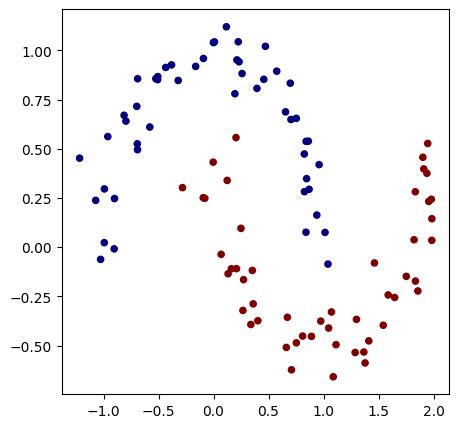

In [19]:
#################### DO NOT MODIFY ####################
X, y = make_moons(n_samples=100, noise=0.1)
y = y*2 - 1 # make y be -1 or 1
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [20]:
#################### DO NOT MODIFY ####################
model = LinearMLP([2, 16, 2]) # 2 layer MLP
X_node = get_node(name='X', value=X.T, op=None, parents=[])
y_onehot = OneHotEncoder().fit_transform(y.reshape(-1,1)).toarray()
y_node = get_node(name='y', value=y_onehot.T, op=None, parents=[])

# Before training
layer_output = model(X_node)
loss = get_node(name='loss', op=SoftmaxCrossEntropyLoss(), parents=[layer_output, y_node])
loss.forward()
loss.backward()

print(loss.value)

0.7645592892448368


In [21]:
def step_network(network, inputs, targets, learning_rate):

    #################### YOUR CODE ############################
    # TODO: Complete the training code using the Node() class,
    #       and operations (if needed) we built earlier.
    #       This function should return the loss from that step.
    #       Hint: refer to the week2 homework code to implement
    #             a new version of the step_network using the Node
    #             and Operations we built
    network.zero_grad()

    node = get_node(name="loss", parents=[network(inputs), targets], op=SoftmaxCrossEntropyLoss())
    node.forward()

    node.backward()
    value = node.value

    for param in network.parameters():
      param.value -= learning_rate * param.grad

    return value
    ##########################################################

def train_linear_mlp(mlp, learning_rate, n_iterations, inputs, targets):
    losses = []
    acc = []
    for _ in range(n_iterations):
        loss = step_network(mlp, inputs, targets, learning_rate)
        losses.append(loss)

    return losses

Accuracy:  0.98


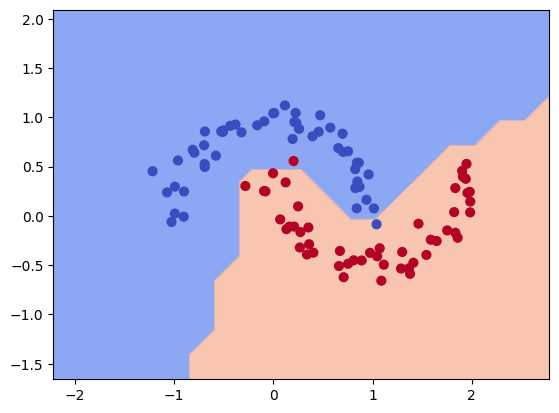

In [22]:
############### SANITY CHECK ###############
SEED = 123
np.random.seed(SEED)

model = LinearMLP([2, 16, 2]) # one layer MLP, input_dim=2, hidden_dim=16, output_dim=2
X_node = get_node(name='X', value=X.T, op=None, parents=[])
y_onehot = OneHotEncoder().fit_transform(y.reshape(-1,1)).toarray()
y_node = get_node(name='y', value=y_onehot.T, op=None, parents=[])
losses = train_linear_mlp(model, 0.2, 500, X_node, y_node)

# accuracy on the train set
out = model(X_node)
out.forward()

print("Accuracy: ", (np.argmax(out.value, axis=0) == ((y > 0) * 1)).mean())
visualize_convergence(model, X, y)